In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
)

Downloading bucket files: 89041311 / 89041311 complete

Downloading bytes: 89041311 / 89041311 complete

In [2]:
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
)
writer.dump()

Writing counts: 2 / 2 complete

In [4]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10
)
ds

Computing RNA initialization statistics: 1 / 1 complete

DataStore has 5025 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_percentRibo', 
            'RNA_nFeatures', 'RNA_nCounts'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'nCells', 'feature_type', 
            'genome', 'dropOuts'

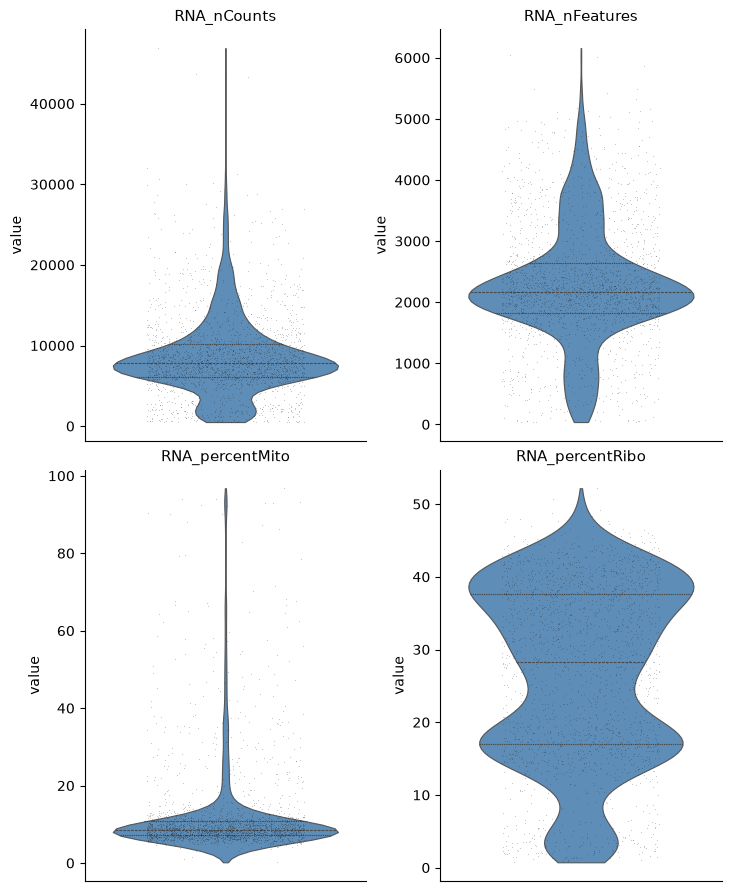

In [5]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

In [6]:
n_before = int(ds.cells.fetch_all('I').sum())
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0]
)
I = ds.cells.fetch_all('I')
print(f'Active cells before filter: {n_before}')
print(f'Active cells after filter: {int(I.sum())}')
print(f'Inactive cells (I=False): {int((~I).sum())}; total in store: {len(I)}')
ds.cells.to_pandas_dataframe(columns=['I'])['I'].value_counts()

Active cells before filter: 5025
Active cells after filter: 3940
Inactive cells (I=False): 1085; total in store: 5025


I
True     3940
False    1085
Name: count, dtype: int64

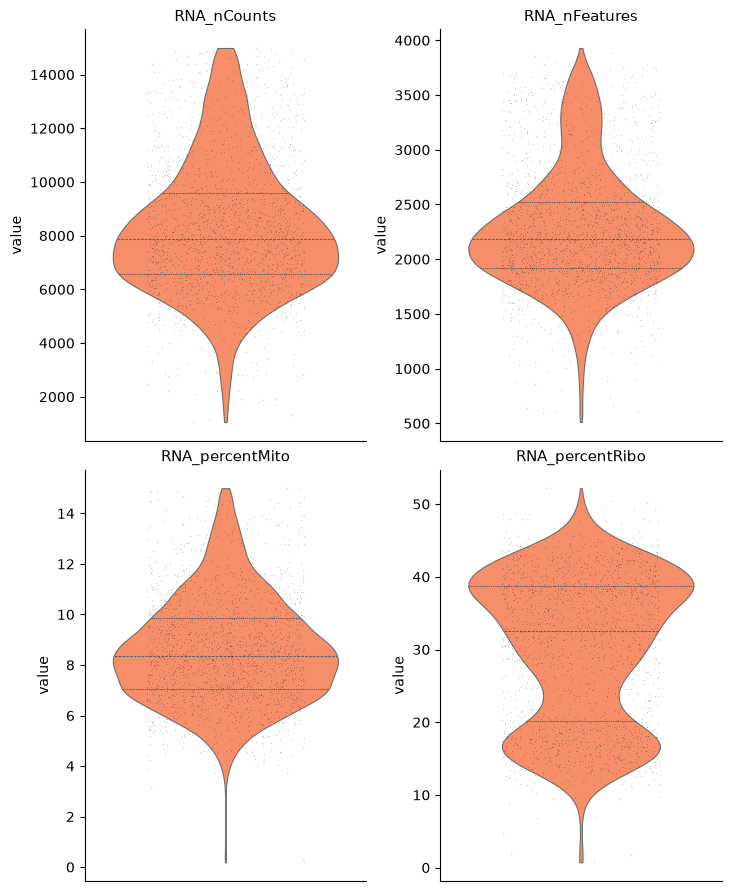

In [7]:
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)

Calculating feature statistics: 30 / 30 complete

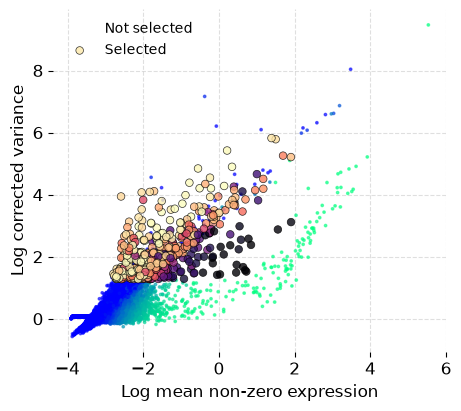

Selected genes: 498


ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='ac2b9f5f2dc9...')

In [8]:
hvg_ref = ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=True,
)
print('Selected genes:', int(ds.RNA.feats.fetch_all('hvgs').sum()))
hvg_ref

In [9]:
normalized = ds.run_normalization(features=hvg_ref)
status = ds.inspect_artifact(normalized)
opts = status.execution_options or {}
print('Size factor (ds.RNA.sf):', ds.RNA.sf)
print('cell_key:', opts.get('cell_key'))
print('feature selection:', status.inputs['feature_selection'])

Writing data: 1 / 1 complete

Size factor (ds.RNA.sf): 1000
cell_key: I
feature selection: {'type': 'artifact', 'scope': 'assay', 'kind': 'feature_selection', 'artifact_id': 'ac2b9f5f2dc9ecdb5b1064fff7ec92bd87cd31e201960efa4c0b2db68677f2be', 'assay': 'RNA'}


Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

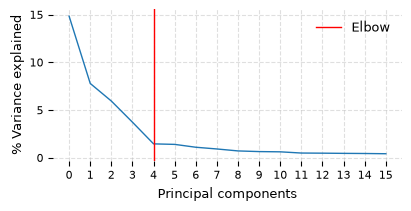

ArtifactRef(assay='RNA', kind='reduction', artifact_id='0c9932ea12f6...')

In [10]:
ds.run_pca(dims=15, show_elbow_plot=True)

In [11]:
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()

graph = ds.load_graph()
degrees = graph.getnnz(axis=1)
print(graph.shape, graph.nnz)
print(
    'Degree min / median / max:',
    int(degrees.min()),
    int(np.median(degrees)),
    int(degrees.max()),
)

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

(3940, 3940) 43340
Degree min / median / max: 11 11 11


In [12]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP: 250 / 250 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='ac51799977d5...')

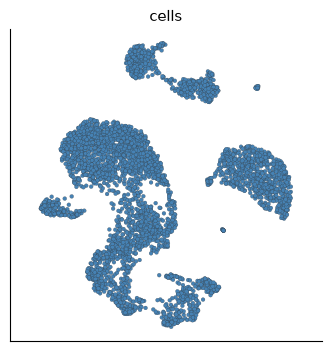

In [13]:
ds.plots.embedding(layout_key='RNA_UMAP')

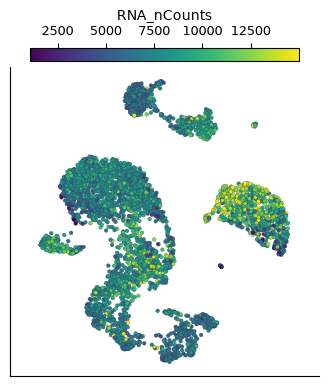

In [14]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
)

In [15]:
ds.run_leiden_clustering(resolution=0.5)
ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)['RNA_leiden_cluster'].value_counts().sort_index()

RNA_leiden_cluster
1      698
2       25
3      235
4     1266
5      318
6      511
7      454
8      143
9      263
10      15
11      12
Name: count, dtype: int64

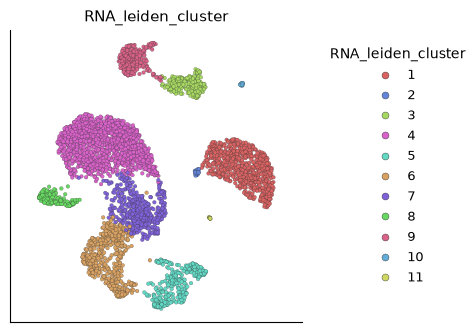

In [16]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [17]:
paris = ds.run_paris_clustering()
ds.cells.to_pandas_dataframe(
    columns=[paris.label_key],
    key='I'
)[paris.label_key].value_counts().sort_index()

RNA_paris_cluster
1      721
2      245
3     1170
4      318
5      534
6      167
7      255
8      503
9       15
10      12
Name: count, dtype: int64

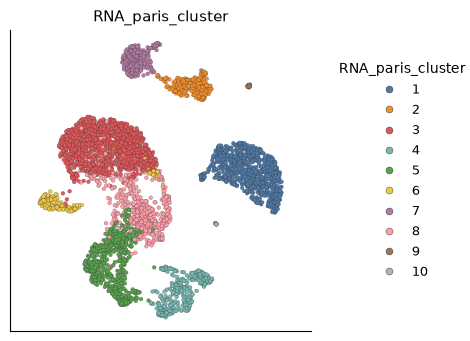

In [18]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris.label_key,
)

In [19]:
pd.crosstab(
    pd.Series(ds.cells.fetch('RNA_leiden_cluster', key='I'), name='Leiden'),
    pd.Series(ds.cells.fetch(paris.label_key, key='I'), name='Paris'),
)

Paris,1,2,3,4,5,6,7,8,9,10
Leiden,,,,,,,,,,
1,696,0,0,0,0,0,2,0,0,0
2,25,0,0,0,0,0,0,0,0,0
3,0,234,0,0,0,0,1,0,0,0
4,0,0,1157,0,0,33,0,76,0,0
5,0,0,0,317,1,0,0,0,0,0
6,0,0,1,1,499,0,0,10,0,0
7,0,0,3,0,34,0,0,417,0,0
8,0,0,9,0,0,134,0,0,0,0
9,0,11,0,0,0,0,252,0,0,0


In [20]:
all_features = ds.resolve_features('RNA', 'all_features')
marker_ref = ds.run_marker_search(
    group_key='RNA_leiden_cluster',
    features=all_features,
)

Finding markers: 2 / 2 complete

Aggregating marker values per group: 1 / 1 complete

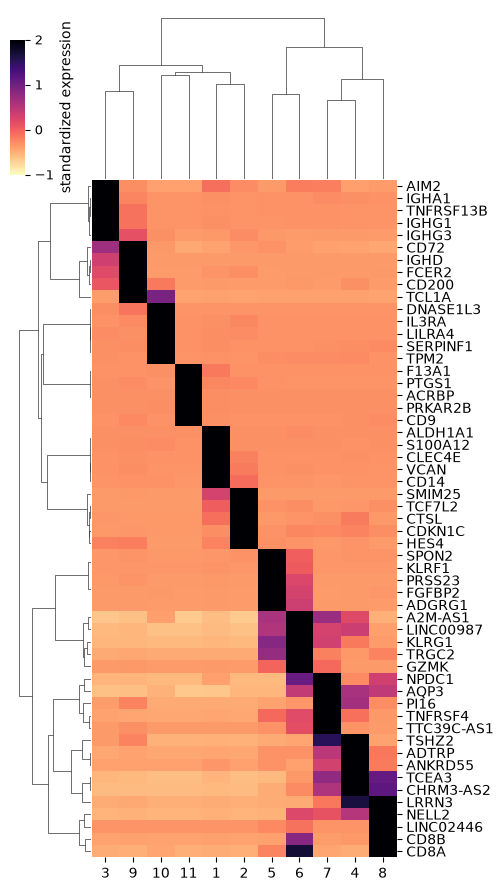

In [21]:
ds.plots.marker_heatmap(
    marker=marker_ref,
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9)
)

In [22]:
df = ds.get_markers(
    marker=marker_ref,
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
df.head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,S100A12,1925,0.94637,1.32931,0.00231,0.95559,0.01295,576.70382,0.0,0.97670,0.0
1,1,VCAN,9167,0.92161,1.48563,0.00465,0.98281,0.03023,319.20089,0.0,0.99070,0.0
2,1,CD14,9635,0.91601,0.93184,0.00253,0.96991,0.01789,368.28125,0.0,0.98420,0.0
3,1,ALDH1A1,16188,0.90086,0.12503,0.00019,0.53152,0.00123,665.04820,0.0,0.76522,0.0
4,1,CLEC4E,20297,0.89682,0.11839,0.00021,0.59742,0.00185,562.32262,0.0,0.79802,0.0


In [23]:
markers = ds.get_markers(
    marker=marker_ref,
    group_key='RNA_leiden_cluster',
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)
panel = markers[markers['feature_name'].isin(['CD14', 'MS4A1', 'CD3D'])]
panel.sort_values(
    ['feature_name', 'score'], ascending=[True, False]
).groupby('feature_name', sort=False).head(2)

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
2,1,CD14,9635,0.91601,0.93184,0.00253,0.96991,0.01789,368.28125,0.000000e+00,0.98420,0.000000e+00
62101,2,CD14,9635,0.04756,0.05383,0.16789,0.32000,0.18570,0.32061,2.872799e-01,0.54189,1.000000e+00
167765,6,CD3D,18652,0.25896,0.69458,0.33277,0.97847,0.57276,2.08726,9.056661e-87,0.76310,8.437286e-84
201358,7,CD3D,18652,0.20820,0.54457,0.35822,0.97797,0.57946,1.52021,2.830919e-37,0.67888,1.309992e-34
268331,9,MS4A1,17795,0.48917,1.12988,0.07421,0.98859,0.09247,15.22584,0.000000e+00,0.96320,0.000000e+00
67092,3,MS4A1,17795,0.48078,1.09192,0.08459,0.99574,0.09879,12.90776,0.000000e+00,0.96130,0.000000e+00


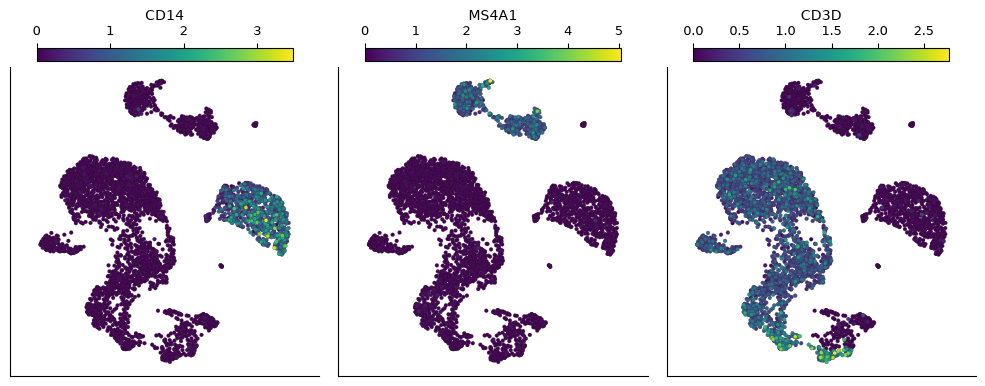

In [24]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)